In [1]:
pip install pillow


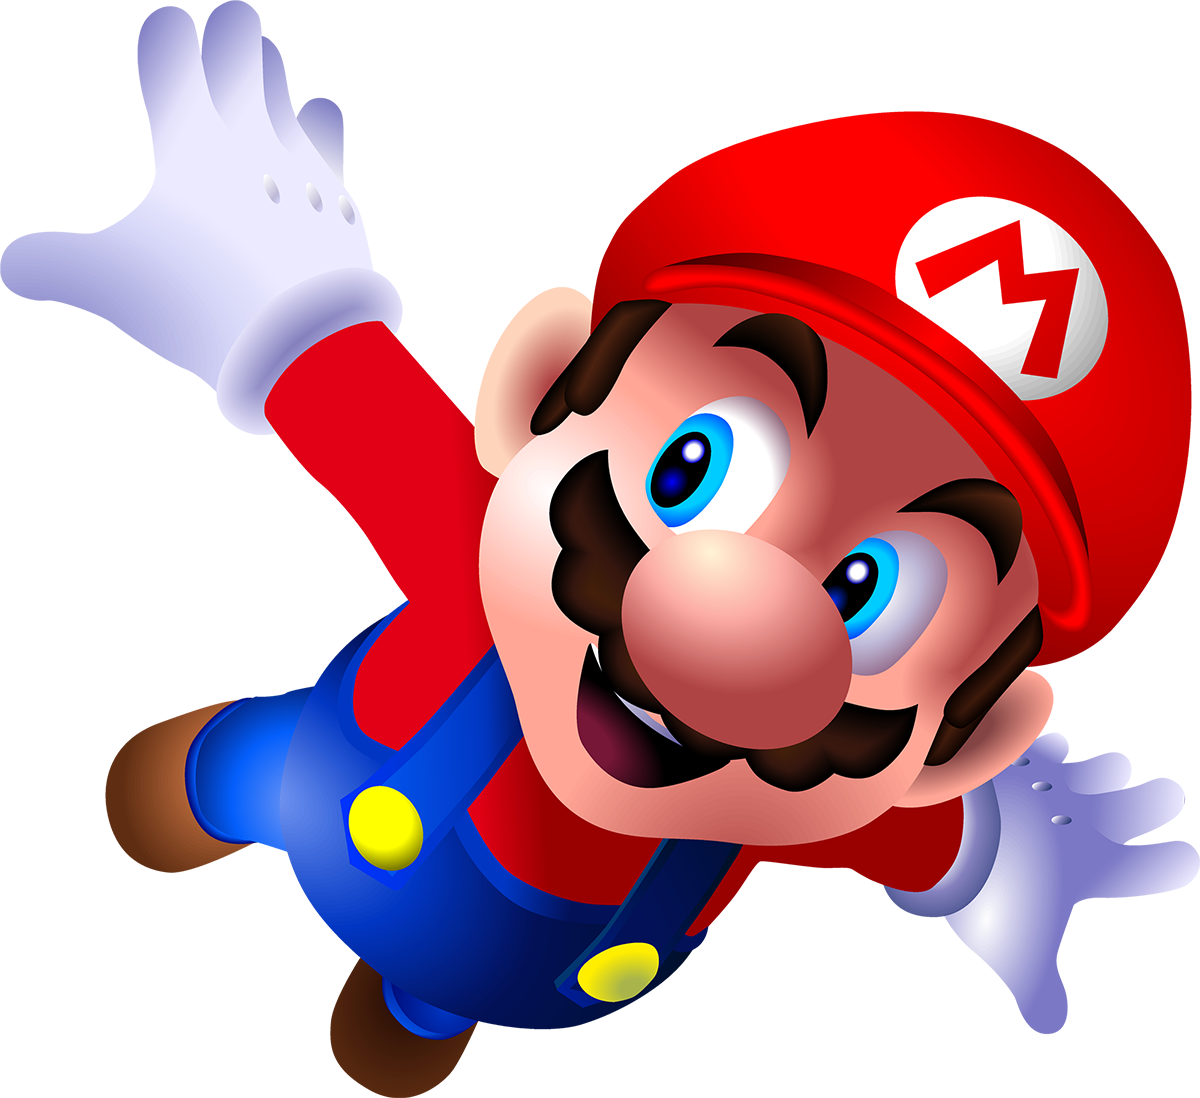

In [4]:
from PIL import Image
# display image in colab
image_colored = Image.open ("/content/drive/MyDrive/mario_PNG125.png")
display ( image_colored )

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
print("Image Format:",image_colored.format)
print("Image Size:",image_colored.size)
print("Image Mode:",image_colored.mode)

Image Format: PNG
Image Size: (1200, 1098)
Image Mode: RGBA


In [15]:
width, height=image_colored.size
channels=len(image_colored.getbands())
print(f"image shape (RGB:({height},{width},{channels}))")
image_size_grayed= width*height*1
print ( f"Image size (RGB): { image_size_grayed }")

image shape (RGB:(1098,1200,4))
Image size (RGB): 1317600


In [16]:
width, height = image_colored.size
channels=len(image_colored.getbands())
print(f"image shape (RGB:({height},{width},{channels})")
image_size_colored=width*height*3
print(f"Image size (RGB):{image_size_colored}")

image shape (RGB:(1098,1200,4)
Image size (RGB):3952800


In [23]:
import numpy as np
# Convert the Pillow image to a NumPy array
image_array_colored = np.array(image_colored)
print("Shape of the image array :", image_array_colored.shape)

# Convert the colored image to grayscale
image_grayed = image_colored.convert('L')
image_array_grayed= np.array(image_grayed)
print ("Shape of the image array :", image_array_grayed.shape )

Shape of the image array : (1098, 1200, 4)
Shape of the image array : (1098, 1200)


In [25]:
# Convert the Pillow image to a NumPy array
image_array_colored = np.array(image_colored)
# Display the shape of the NumPy array (height, width, channels)
print("Shape of the image array :", image_array_colored.shape)
#For Red Channels
red_channel = image_array_colored[:, :, 0] # Red channel
print(red_channel)
display(red_channel)
# For Green Channels
green_channel = image_array_colored[:, :, 1] # Green channel
print(green_channel)
display(green_channel)

Shape of the image array : (1098, 1200, 4)
[[128 128 128 ... 255 255 255]
 [128 128 128 ... 255 255 255]
 [128 128 128 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


array([[128, 128, 128, ..., 255, 255, 255],
       [128, 128, 128, ..., 255, 255, 255],
       [128, 128, 128, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)

[[128 128 128 ... 255 255 255]
 [128 128 128 ... 255 255 255]
 [128 128 128 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


array([[128, 128, 128, ..., 255, 255, 255],
       [128, 128, 128, ..., 255, 255, 255],
       [128, 128, 128, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)

In [26]:
# For Blue Channel :
blue_channel = image_array_colored [: , : , 2] # Blue channel
print ( blue_channel )
display ( blue_channel )

[[189 189 189 ... 255 255 255]
 [189 189 189 ... 255 255 255]
 [189 189 189 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


array([[189, 189, 189, ..., 255, 255, 255],
       [189, 189, 189, ..., 255, 255, 255],
       [189, 189, 189, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)

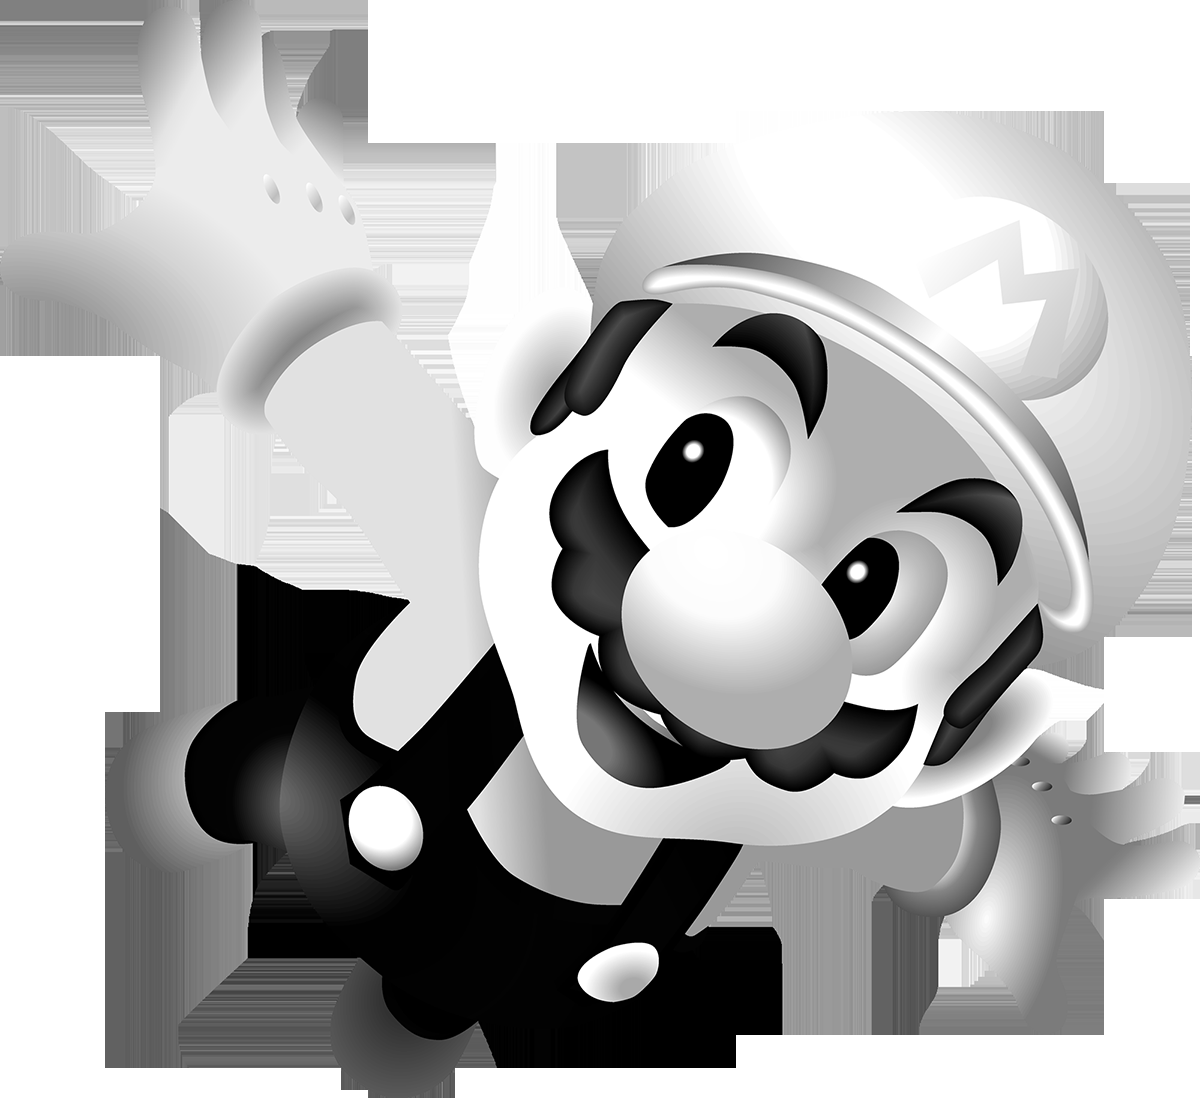

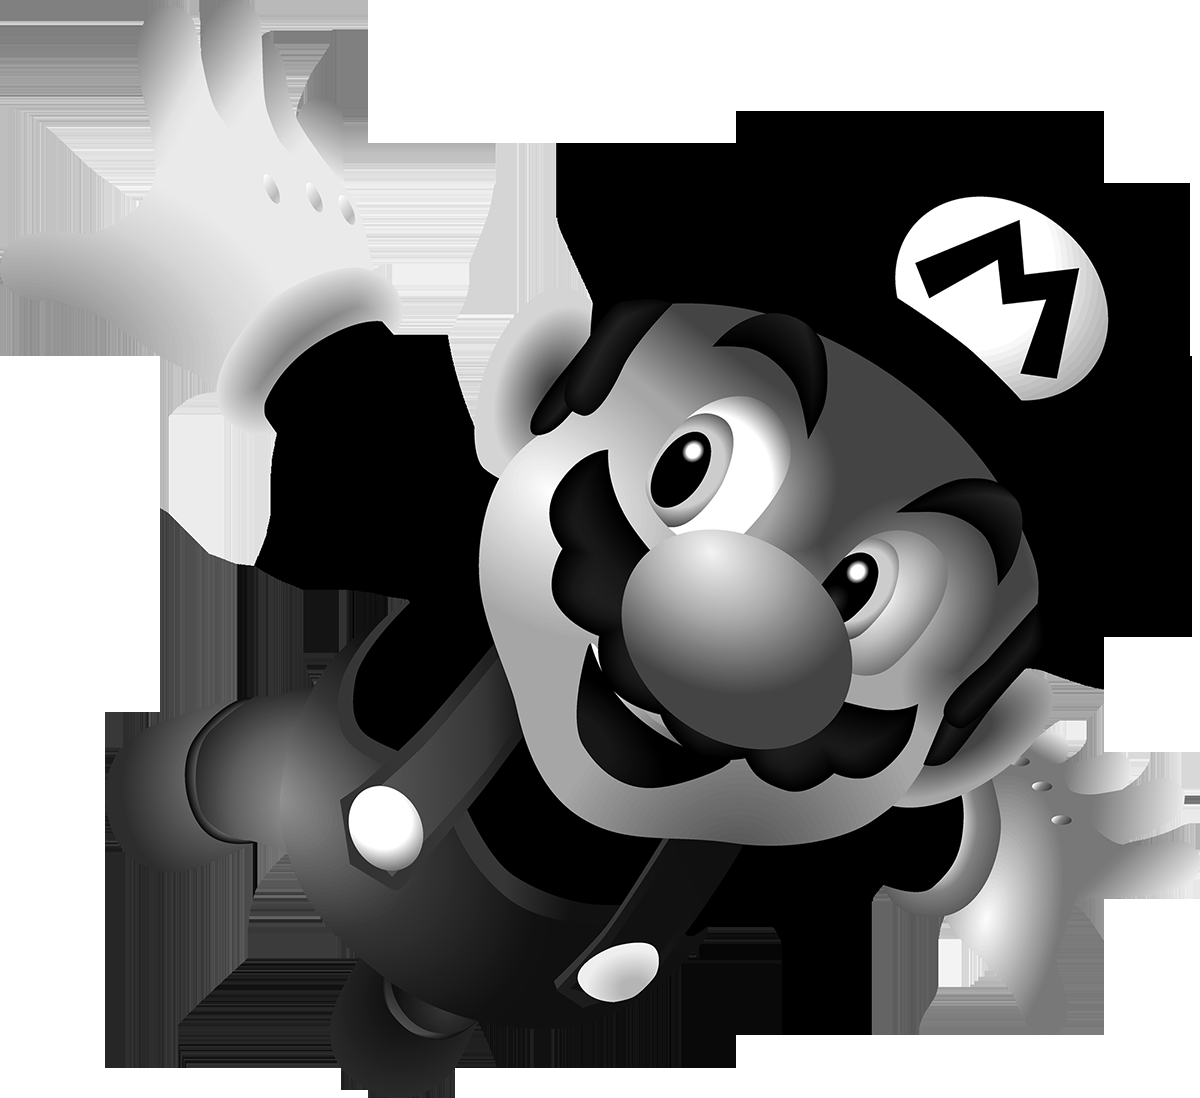

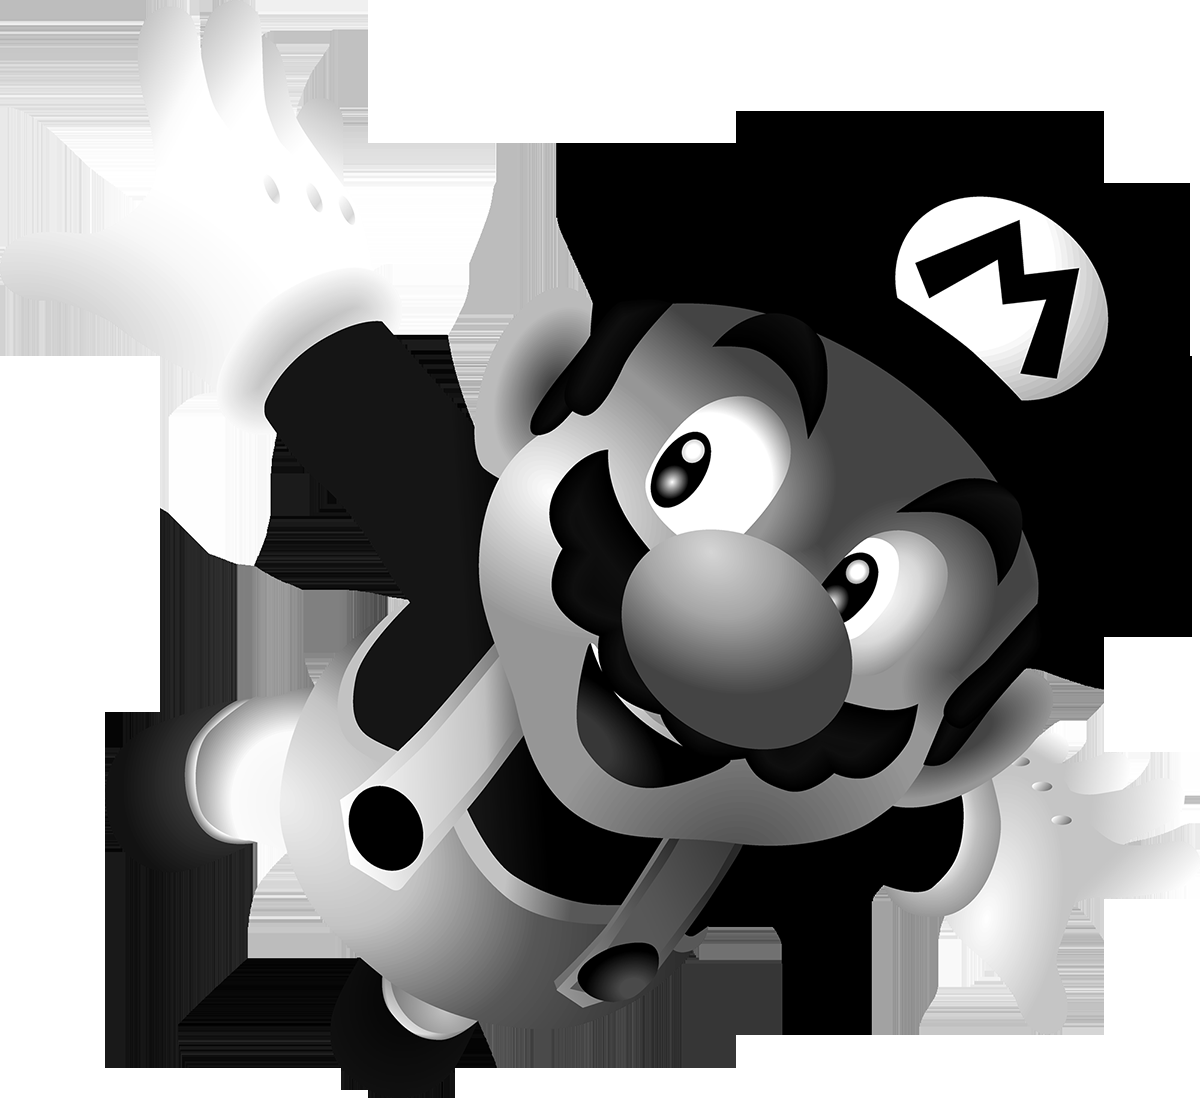

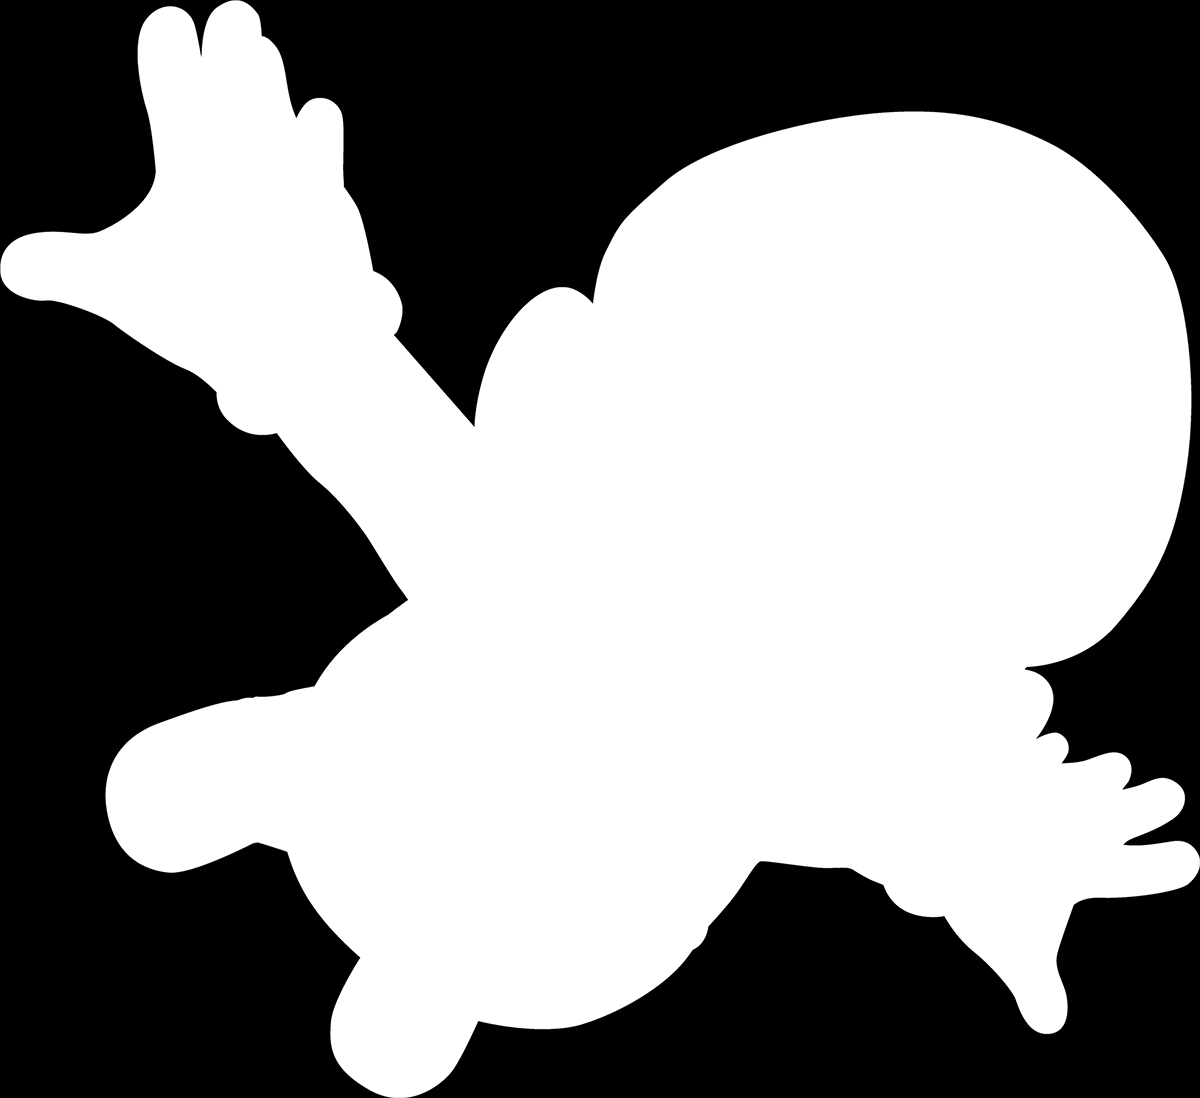

In [28]:
# Assuming image_colored is already defined and loaded above
# Get the R, G, B, and Alpha channels
r , g , b , a = image_colored . split ()
# Display or further process the individual channels
display ( r )
display ( g )
display ( b )
display ( a )

In [31]:
# Sample Implementation :
# Accessing a specific row - 100 th row
row_100 = image_array_colored [100 , : , :]
# Accessing a specific column - 50 th col
col_50 = image_array_colored [: , 50 , :]
# Accessing a specific pixel (row 10 , col 20)
pixel = image_array_colored [10 , 20 , :] # Gets RGB values at (10 ,20)

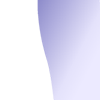

In [32]:
# Define the cropping box (left, upper, right, lower)
left = 100
upper = 50
right = 200
lower = 150
# Crop the image
cropped_image = image_colored.crop((left, upper, right, lower))
# Display the cropped image
display(cropped_image)

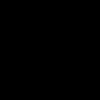

In [34]:
# Create a NumPy array (Here, we use a dummy array for illustration)
image_array = np.zeros((100, 100, 3), dtype=np.uint8) # Example: black image
# Convert the NumPy array back to a Pillow Image object
image_from_array = Image.fromarray(image_array)
# Display the image
display(image_from_array)
# Optionally save the image to a file
image_from_array.save("output_image.jpg")

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
# Load image and convert to grayscale
image = Image.open("/content/drive/MyDrive/mario_PNG125.png").convert("L")
# Convert to NumPy array
image_array = np.array(image)
# Get image dimensions
height , width = image_array.shape
# Reshape the image into a 2D array where each row represents a row of pixels
# This allows PCA to process each row as an observation and find patterns across pixel intensities
data = image_array.reshape(height , width)

In [45]:
#Compute the mean of each column ( feature )
import numpy as np
mean = np . mean ( data , axis =0)
# Subtract mean to center the data
centered_data = data - mean
# Compute covariance matrix
cov_matrix = np . cov ( centered_data , rowvar = False )
# Compute eigenvalues and eigenvectors
eigenvalues , eigenvectors = np . linalg . eigh ( cov_matrix )
# Sort eigenvalues and corresponding eigenvectors indescending order
sorted_indices = np . argsort ( eigenvalues ) [:: -1]
eigenvalues = eigenvalues [ sorted_indices ]
eigenvectors = eigenvectors [: , sorted_indices ]

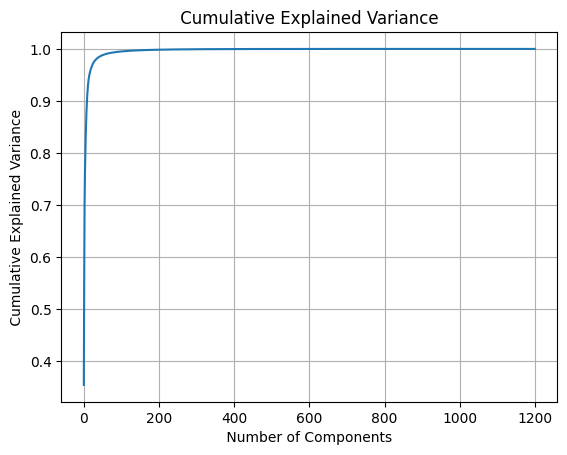

In [46]:
import numpy as np
# Plot the explained variance ratio
explained_variance_ratio = eigenvalues / np .sum ( eigenvalues )
plt . plot ( np . cumsum ( explained_variance_ratio ) )
plt . title (" Cumulative Explained Variance ")
plt . xlabel (" Number of Components ")
plt . ylabel (" Cumulative Explained Variance ")
plt . grid ( True )
plt . show ()

In [47]:
k = 50 # Choose k principal components
components = eigenvectors [: , : k ]

In [54]:
import numpy as np
# Project the data onto the principal components
compressed_data = np . dot ( centered_data , components )
# Reconstruct the image from compressed data
decompressed_data = np . dot ( compressed_data , components . T ) +mean

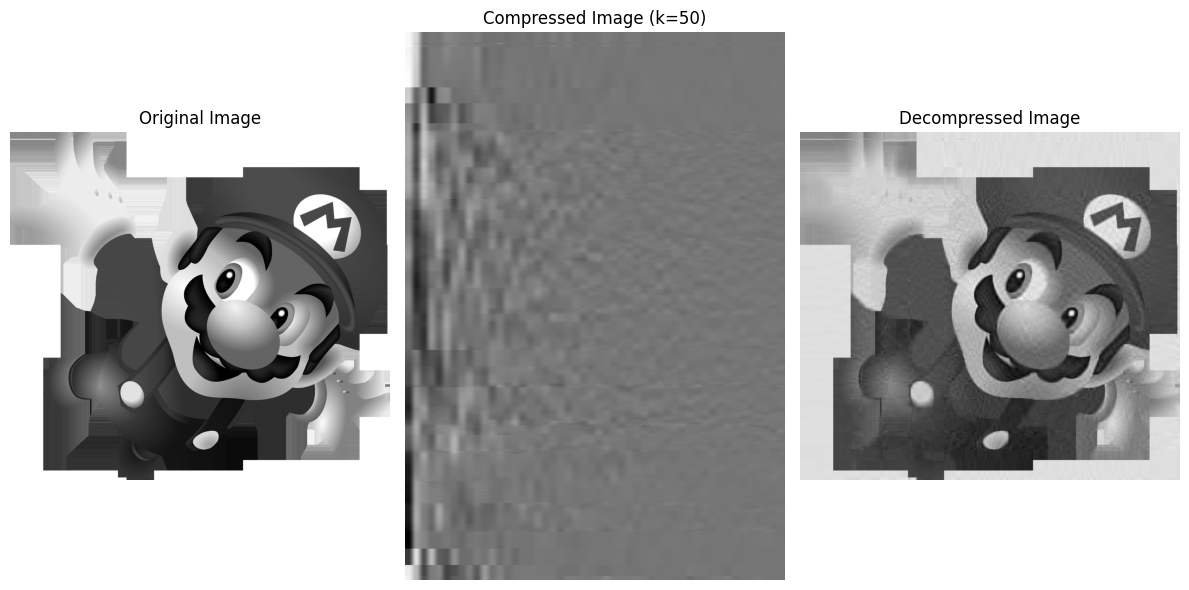

In [58]:
plt.figure(figsize=(12, 6))
# Original Image
plt.subplot(1, 3, 1)
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")
# Compressed Representation
plt.subplot(1, 3, 2)
plt.imshow(compressed_data, cmap="gray", aspect="auto")
plt.title(f"Compressed Image (k={k})")
plt.axis("off")
# Decompressed Image
plt.subplot(1, 3, 3)
plt.imshow(decompressed_data, cmap="gray")
plt.title("Decompressed Image")
plt.axis("off")
plt.tight_layout()
plt.show()